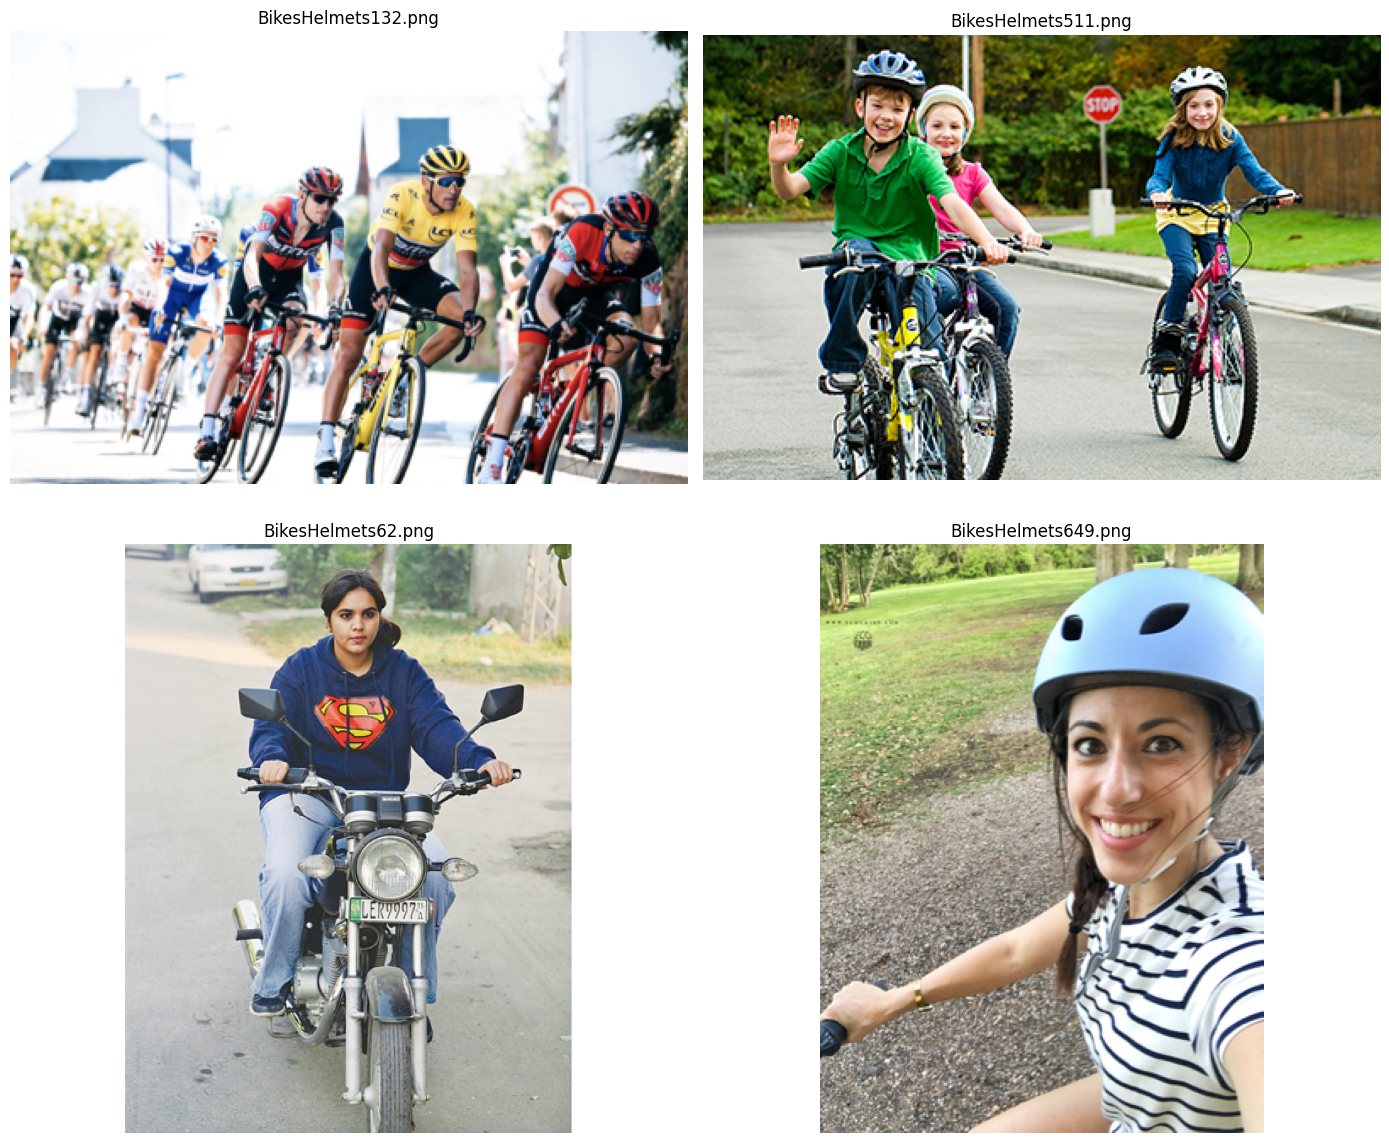

In [1]:
import random
import cv2
import matplotlib.pyplot as plt
import os

PROCESSED_DIR = '../dataset/processed_yolo'

# Ambil 4 gambar dari train
train_images_dir = os.path.join(PROCESSED_DIR, 'train', 'images')
sample_imgs = random.sample(os.listdir(train_images_dir), 4)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, img_name in enumerate(sample_imgs):
    img_path = os.path.join(train_images_dir, img_name)
    label_path = os.path.join(PROCESSED_DIR, 'train', 'labels', img_name.replace('.png', '.txt').replace('.jpg', '.txt'))
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id, x_c, y_c, bw, bh = map(float, parts)
                x1 = int((x_c - bw/2) * w)
                y1 = int((y_c - bh/2) * h)
                x2 = int((x_c + bw/2) * w)
                y2 = int((y_c + bh/2) * h)
                color = (0, 255, 0) if cls_id == 0 else (255, 0, 0)
                label = "Helm" if cls_id == 0 else "No Helm"
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'{img_name}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [2]:
def count_classes(subset):
    label_dir = os.path.join(PROCESSED_DIR, subset, 'labels')
    counts = {0: 0, 1: 0}
    for txt_file in os.listdir(label_dir):
        with open(os.path.join(label_dir, txt_file), 'r') as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                if cls_id in counts:
                    counts[cls_id] += 1
    return counts

for subset in ['train', 'val', 'test']:
    counts = count_classes(subset)
    print(f"{subset}: With={counts[0]}, Without={counts[1]}")

train: With=0, Without=0
val: With=0, Without=0
test: With=0, Without=0
